1839
1838
Imported featurewiz_polars 0.3.0. Use the following syntax:
 >> from featurewiz_polars import FeatureWiz, FeatureWiz_Model
    
f1:  0.8833138856476079
acc： 0.8731769181991123
pcc： 0.8174946004319654
rcc： 0.9606598984771574


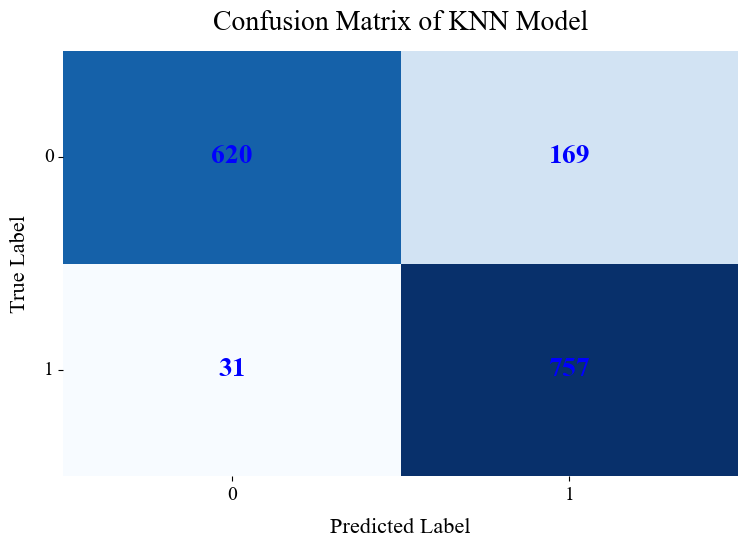

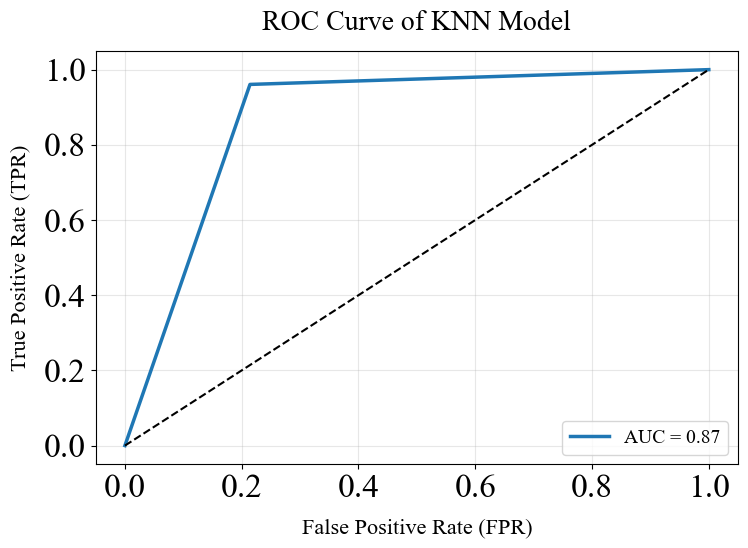

In [2]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split

smote = SMOTE(k_neighbors=5)  # 5是邻居数量的一个示例值
data = pd.read_csv('怀化数据20250504_完整_填充缺失值.csv',sep=',')
df = pd.DataFrame(data)

target = '苏醒延迟60'
features = df.columns.drop(['苏醒延迟60','转出延迟'])

X, y = df[features], df[target]

ros = RandomOverSampler(random_state=0)
X_resampled, y_resampled = ros.fit_resample(X, y)

X_train,X_test,y_train,y_test = train_test_split(X_resampled,y_resampled,test_size = 0.3,random_state = 7)
print(len(y_train[y_train == 1]))
print(len(y_train[y_train == 0]))

from PODAA_Model import PODAA
podaa = PODAA(X_train,X_test,y_train,y_test,features)

podaa.KNN_Model()

Best parameters: {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation score: 0.6842472641230405
f1:  0.695376820772641
acc： 0.6949904882688649
pcc： 0.6940581542351454
rcc： 0.6967005076142132 



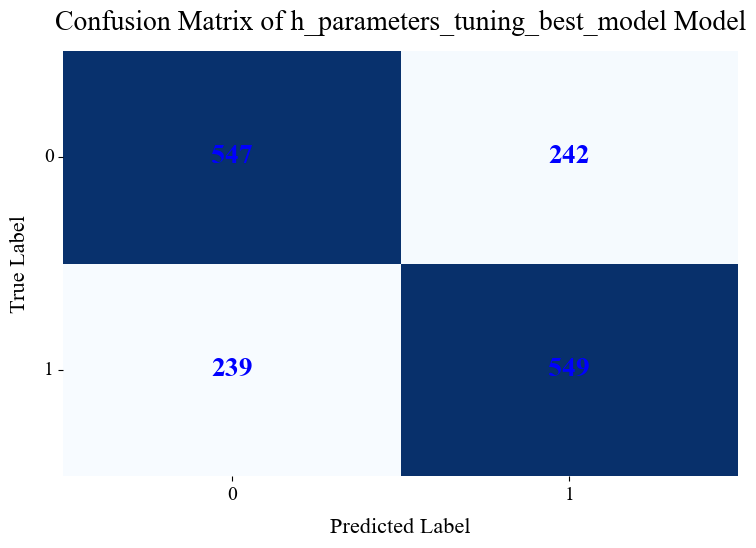

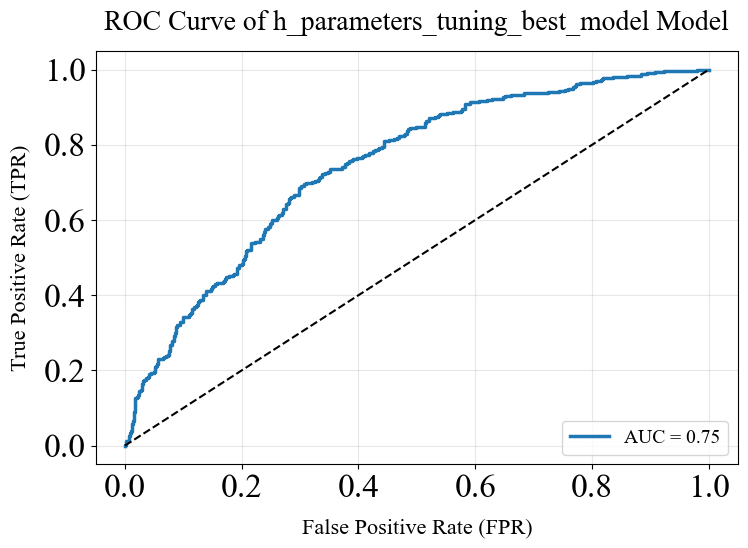

NameError: name 'random_search' is not defined

In [3]:
## LR超参数调优
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

# 定义超参数网格
param_grid = {
    'penalty':['l1','l2'],
    'C': [0.1, 1, 10, 100],  # 正则化强度的倒数
    'solver': ['liblinear', 'lbfgs']  # 求解器
}

podaa.h_parameters_tuning(model,param_grid)


Best parameters: {'class_weight': 'balanced', 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation score: 0.9186823425022184
f1:  0.94625
acc： 0.9454660748256183
pcc： 0.9322660098522167
rcc： 0.9606598984771574 



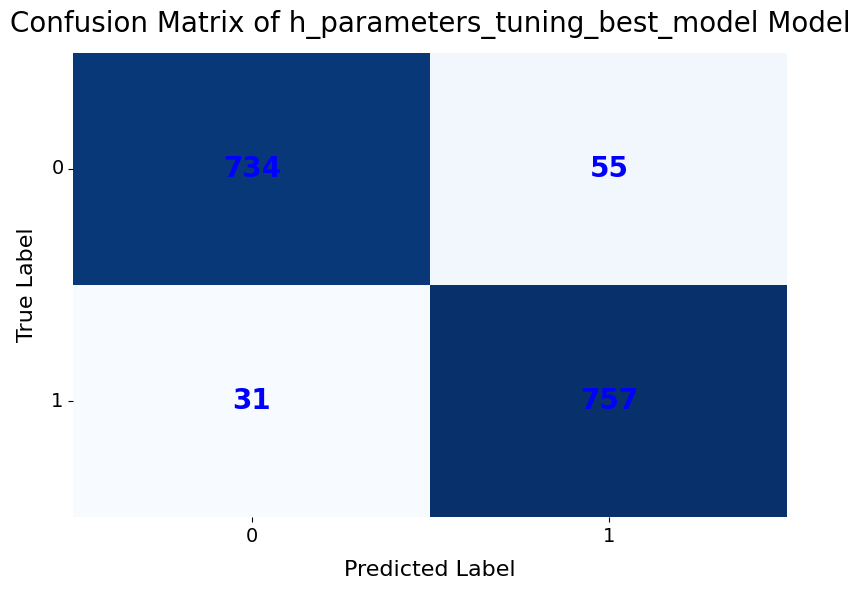

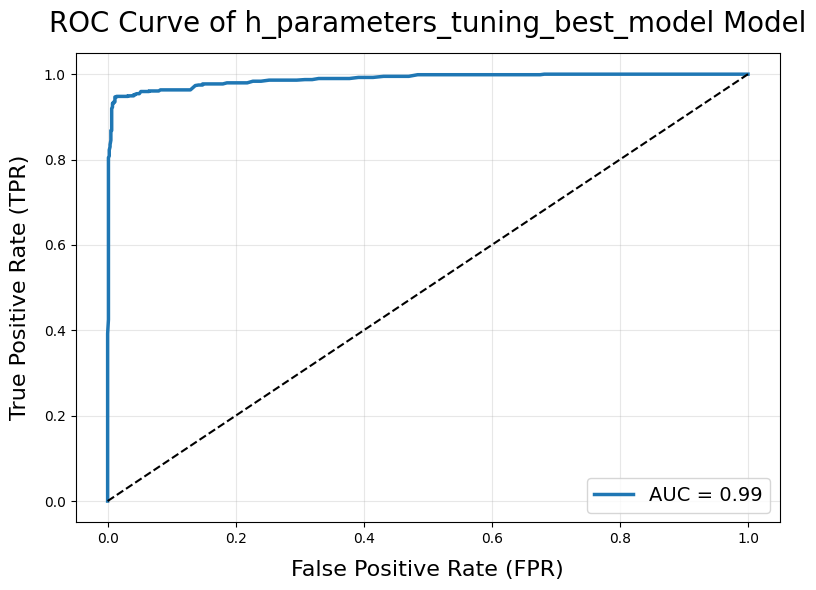

In [3]:
## RF超参数调优
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(bootstrap=True,random_state=42)

# 定义超参数网格
param_grid = {
    'max_features':['sqrt'],
    'min_samples_split':list(range(1, 15)),
    'min_samples_leaf':list(range(1, 15)),
    'class_weight':['balanced','none'],
    'n_estimators':[100,150,200],
    'max_depth':[5,10,15,20,25,30],
}

podaa.h_parameters_tuning(model,param_grid)

Best parameters: {'metric': 'manhattan', 'n_neighbors': 1, 'p': 1, 'weights': 'uniform'}
Best cross-validation score: 0.8466152765454009
f1:  0.8833138856476079
acc： 0.8731769181991123
pcc： 0.8174946004319654
rcc： 0.9606598984771574 



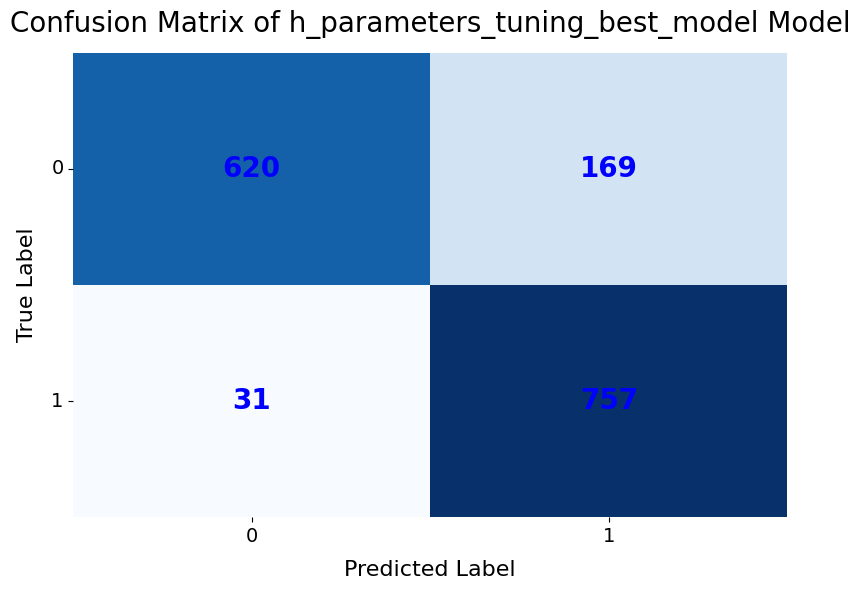

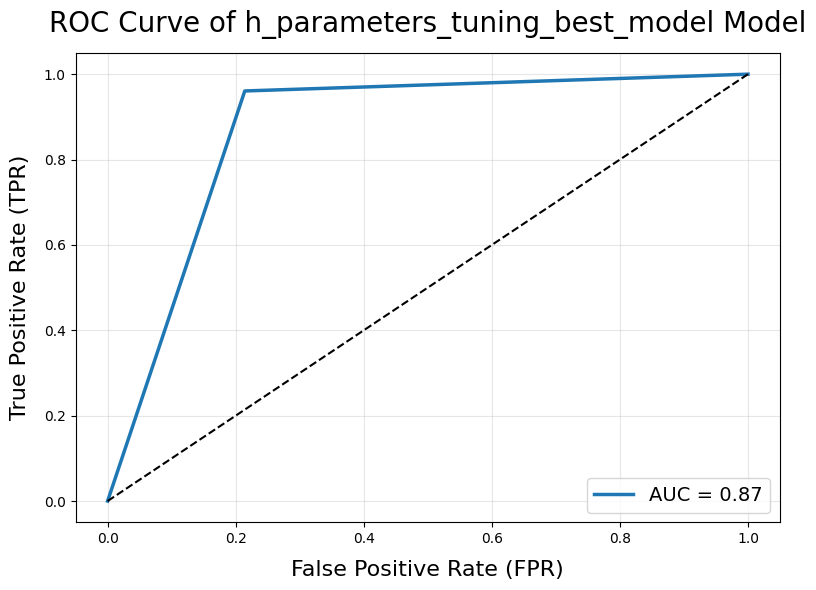

In [5]:
## KNN超参数调优
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier()

# 定义超参数网格
param_grid = {
    'n_neighbors': list(range(1, 31)),  # 邻居数量
    'weights': ['uniform', 'distance'],  # 权重函数
    'metric': ['euclidean', 'manhattan', 'minkowski'],  # 距离度量
    'p': [1, 2]  # 明可夫斯基距离的参数
}

podaa.h_parameters_tuning(model,param_grid)

Best parameters: {'alpha': 0.1, 'binarize': 0.5, 'fit_prior': False}
Best cross-validation score: 0.6570489500147885
f1:  0.6503368034292712
acc： 0.6379201014584654
pcc： 0.6284023668639053
rcc： 0.6738578680203046 



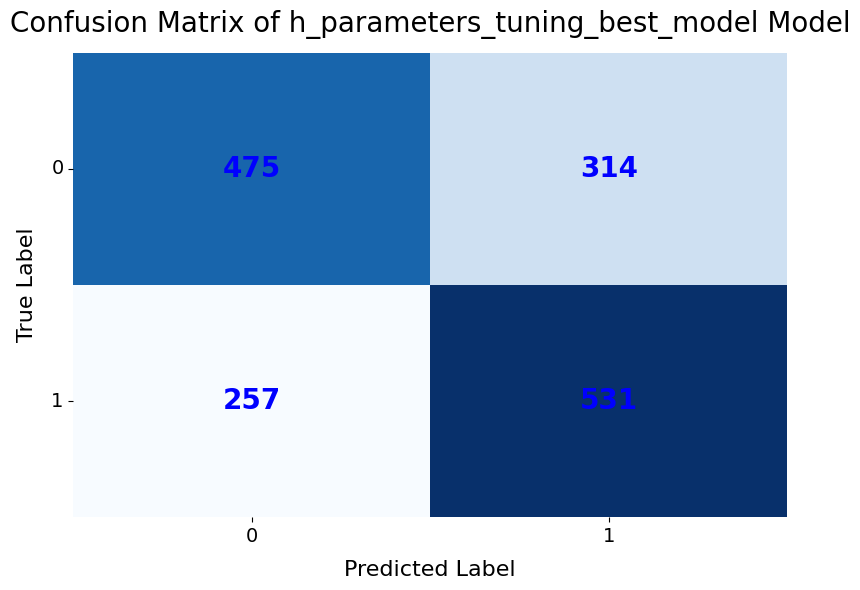

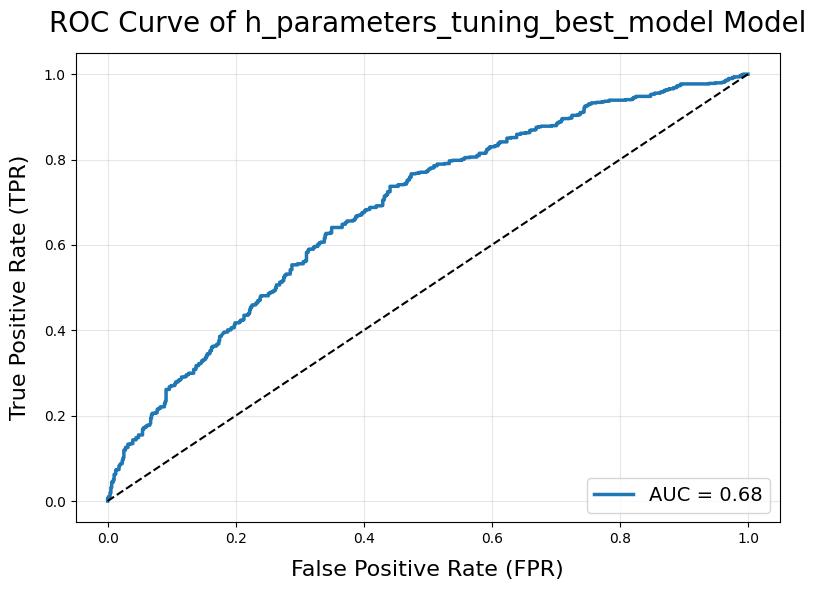

In [7]:
## NB超参数调优
from sklearn.naive_bayes import BernoulliNB

model = BernoulliNB()

# 定义超参数网格
param_grid = {
    'alpha': [0.1, 0.5, 1.0, 2.0, 5.0],  # 平滑参数
    'fit_prior': [True, False],  # 是否学习先验概率
    'binarize': [0.0, 0.5, 1.0]  # 二值化阈值
}

podaa.h_parameters_tuning(model,param_grid)

Best parameters: {'n_components': None, 'shrinkage': None, 'solver': 'svd'}
Best cross-validation score: 0.6858806566104703
f1:  0.6844783715012722
acc： 0.6854787571337984
pcc： 0.6862244897959183
rcc： 0.682741116751269 



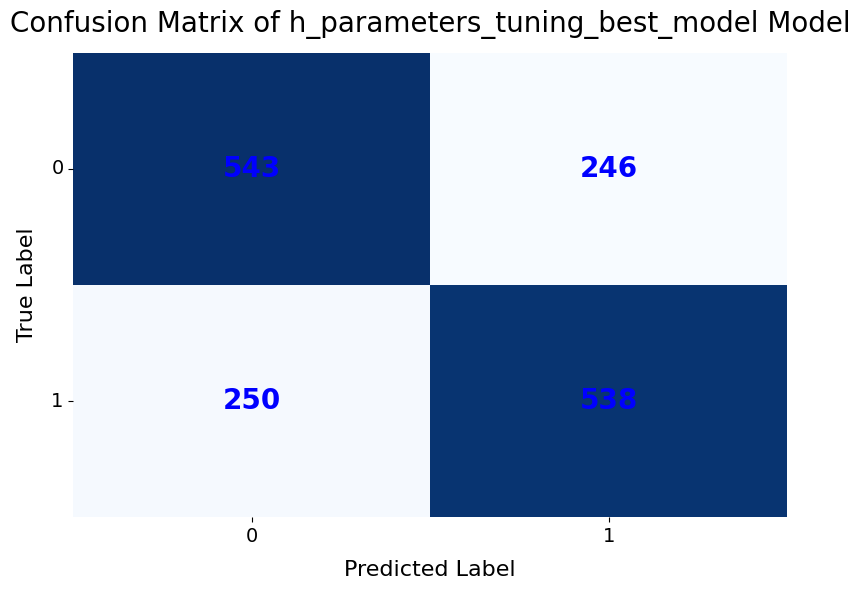

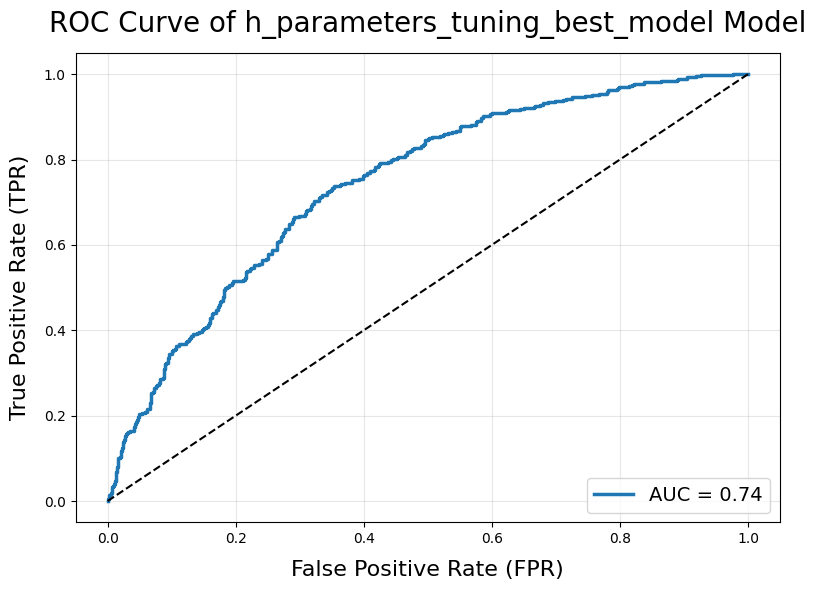

In [2]:
## LDA超参数调优
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

model = LinearDiscriminantAnalysis()

# 定义超参数网格
param_grid = {
    'solver': ['svd', 'lsqr', 'eigen'],  # 求解器类型
    'shrinkage': [None, 0.0, 0.1, 0.5, 1.0],  # 收缩参数
    'n_components': [None, 1, 2]  # 降维后的特征数量
}

podaa.h_parameters_tuning(model,param_grid)

In [ ]:
## XGBoost超参数调优
from xgboost.sklearn import XGBClassifier

model = XGBClassifier(class_weight='balanced',
                            booster='dart',  # 给定模型求解方式 可选参数gbtree、gblinear、dart
                            objective='multi:softmax',
                            num_class=2,
                            reg_lambda=2,  # 权重的L2正则化项。(和Ridge regression类似)。这个参数是用来控制XGBoost的正则化部分的。这个参数在减少过拟合上很有帮助。
                            eta=0.1,  # 每一步迭代的步长
                            seed=1000,
                            nthread=4,  # 使用的线程数
                            eval_metric=['mlogloss', 'merror'],  # 设置 XGBoost 使用softmax目标函数做多分类，需要设置参数num_class（类别个数）
                            reg_alpha=1,  #L1正则化权重项，增加此值将使模型更加保守
                            random_state=42
                            )

# 定义超参数网格
param_grid = {
            'gamma':[0.1,1,10],  
            'max_depth':[5,10,15,20,25,30],  
            'subsample':[0.1,0.3,0.5,0.7,0.8,1],  
            'colsample_bytree':[0.1,0.3,0.5,0.7,0.8,1], 
            'min_child_weight':list(range(1, 10)),  
            'n_estimators':[5,10,15,20], 
            'learning_rate':[0.01,0.1], 
}

podaa.h_parameters_tuning(model,param_grid)

